In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for the assignment
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# Load the dataset
df = pd.read_csv('mnist_test.csv')

# The first column is 'label'. Let's separate it from the pixel features.
y = df['label']
X = df.drop('label', axis=1)

print(f"Features shape: {X.shape} (10000 images, 784 pixels each)")
print(f"Labels shape: {y.shape}")

Features shape: (10000, 784) (10000 images, 784 pixels each)
Labels shape: (10000,)


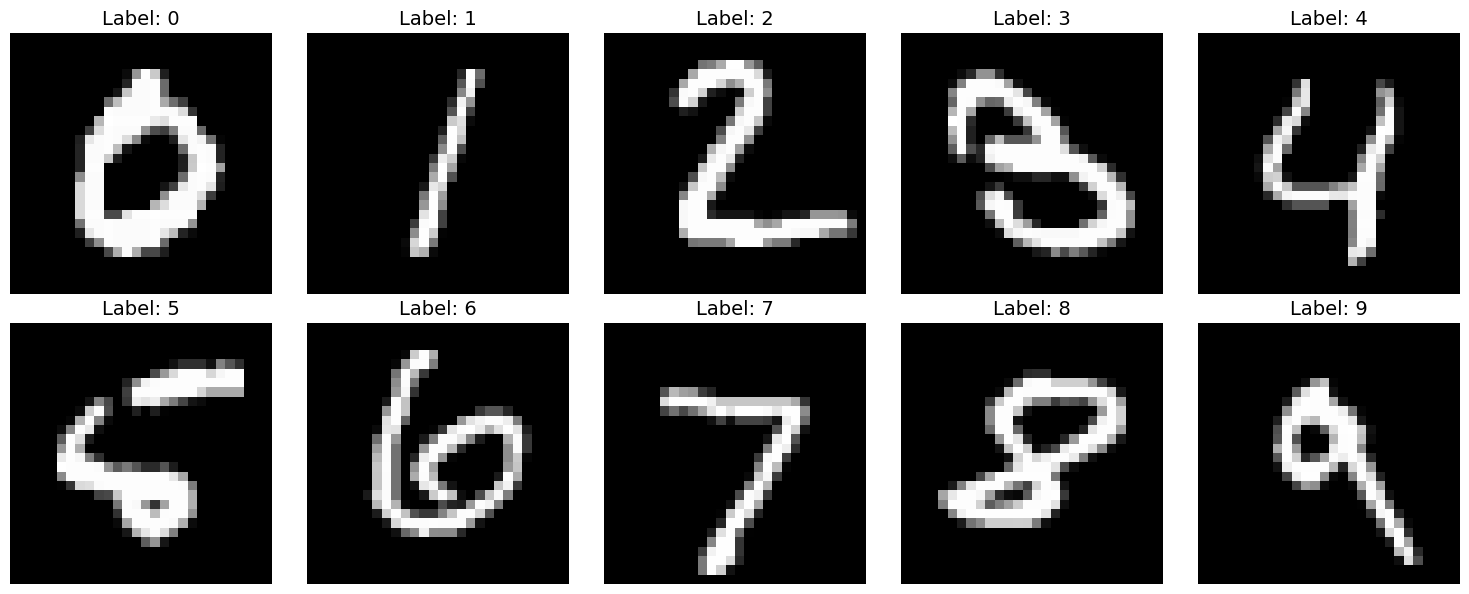

In [3]:
import matplotlib.pyplot as plt

# Set up a figure with a specific size (width=15, height=6)
plt.figure(figsize=(15, 6))

# Loop through the numbers 0 to 9
for digit in range(10):
    # Find the very first row in our dataset that matches the current digit
    # (e.g., find the first '0', then the first '1', etc.)
    first_occurrence_idx = y[y == digit].index[0]
    
    # Extract those 784 pixel values and reshape them into a 28x28 image grid
    raw_pixels = X.loc[first_occurrence_idx].values
    image_matrix = raw_pixels.reshape(28, 28)
    
    # Create a subplot in a 2-row, 5-column grid
    plt.subplot(2, 5, digit + 1)
    
    # Draw the image in grayscale
    plt.imshow(image_matrix, cmap='gray')
    
    # Add a title to each subplot
    plt.title(f"Label: {digit}", fontsize=14)
    
    # Turn off the axis measurements (we don't need to see 0-28 on the edges)
    plt.axis('off')

# Automatically adjust the spacing so the titles don't overlap
plt.tight_layout()
plt.show()

In [4]:
# 1. Standardize the data (gives it a mean of 0 and variance of 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA to reduce dimensions from 784 to 50
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Let's see how much information (variance) we retained
variance_retained = pca.explained_variance_ratio_.sum() * 100
print(f"Data reduced to 50 dimensions. Variance retained: {variance_retained:.2f}%")

Data reduced to 50 dimensions. Variance retained: 60.38%


In [5]:
# Apply t-SNE to reduce from 50 down to 2 dimensions
print("Running t-SNE... (this usually takes 1 to 2 minutes)")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

print("t-SNE finished!")

Running t-SNE... (this usually takes 1 to 2 minutes)
t-SNE finished!


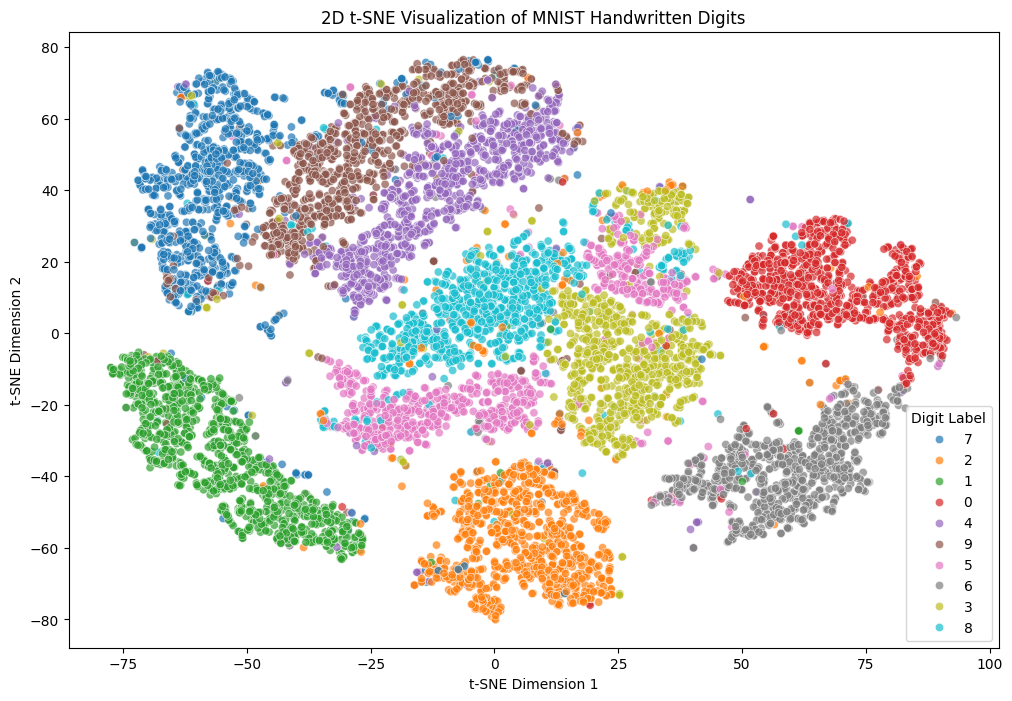

In [6]:
# Create a new DataFrame specifically for plotting
plot_df = pd.DataFrame(data=X_tsne, columns=['TSNE_1', 'TSNE_2'])

# Add the labels back in, converting them to strings so Seaborn treats them as distinct categories
plot_df['Digit Label'] = y.astype(str)

# Set up the matplotlib figure size
plt.figure(figsize=(12, 8))

# Create the scatterplot using Seaborn
sns.scatterplot(
    x='TSNE_1', 
    y='TSNE_2',
    hue='Digit Label',
    palette='tab10', # A built-in color palette with 10 distinct colors
    data=plot_df,
    legend="full",
    alpha=0.7 # Makes the dots slightly transparent
)

# Add titles and labels
plt.title('2D t-SNE Visualization of MNIST Handwritten Digits')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Display the plot
plt.show()

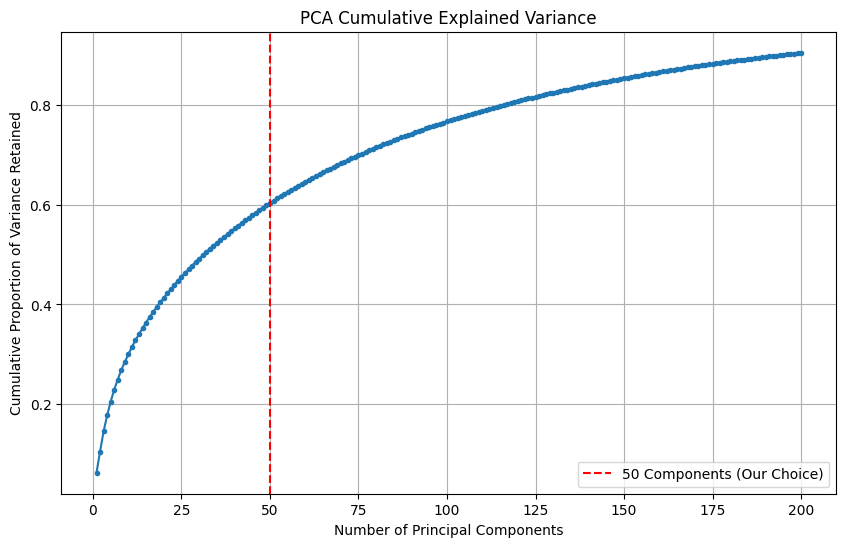

In [7]:
# --- GRAPH 1: PCA EXPLAINED VARIANCE PLOT ---
# Fit PCA on the scaled data (let's look at the first 200 components)
pca_full = PCA(n_components=200, random_state=42)
pca_full.fit(X_scaled)

# Calculate the cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 201), cumulative_variance, marker='.', linestyle='-')

# Add a red line at x=50 to show the choice we made for the assignment
plt.axvline(x=50, color='red', linestyle='--', label='50 Components (Our Choice)')

plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Proportion of Variance Retained')
plt.legend()
plt.grid(True)
plt.show()

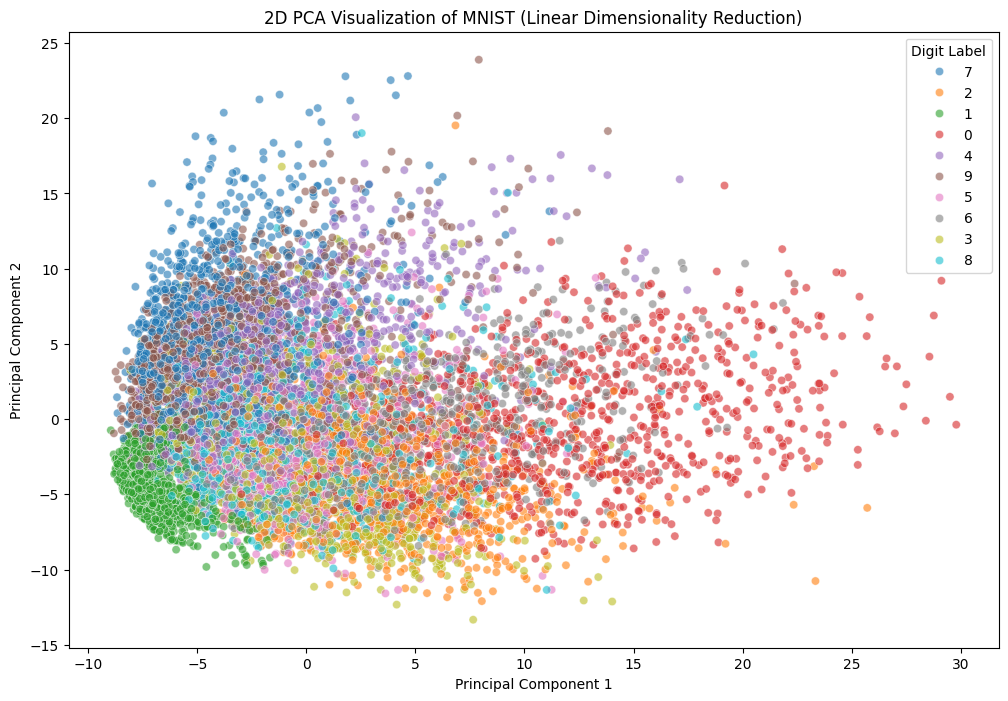

In [8]:
# --- GRAPH 2: 2D PCA VISUALIZATION (FOR COMPARISON) ---
# Reduce data to exactly 2 dimensions using PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Digit Label'] = y.astype(str) # Convert to string for distinct colors

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2',
    hue='Digit Label',
    palette='tab10',
    data=pca_df,
    legend="full",
    alpha=0.6 # Slight transparency
)

plt.title('2D PCA Visualization of MNIST (Linear Dimensionality Reduction)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

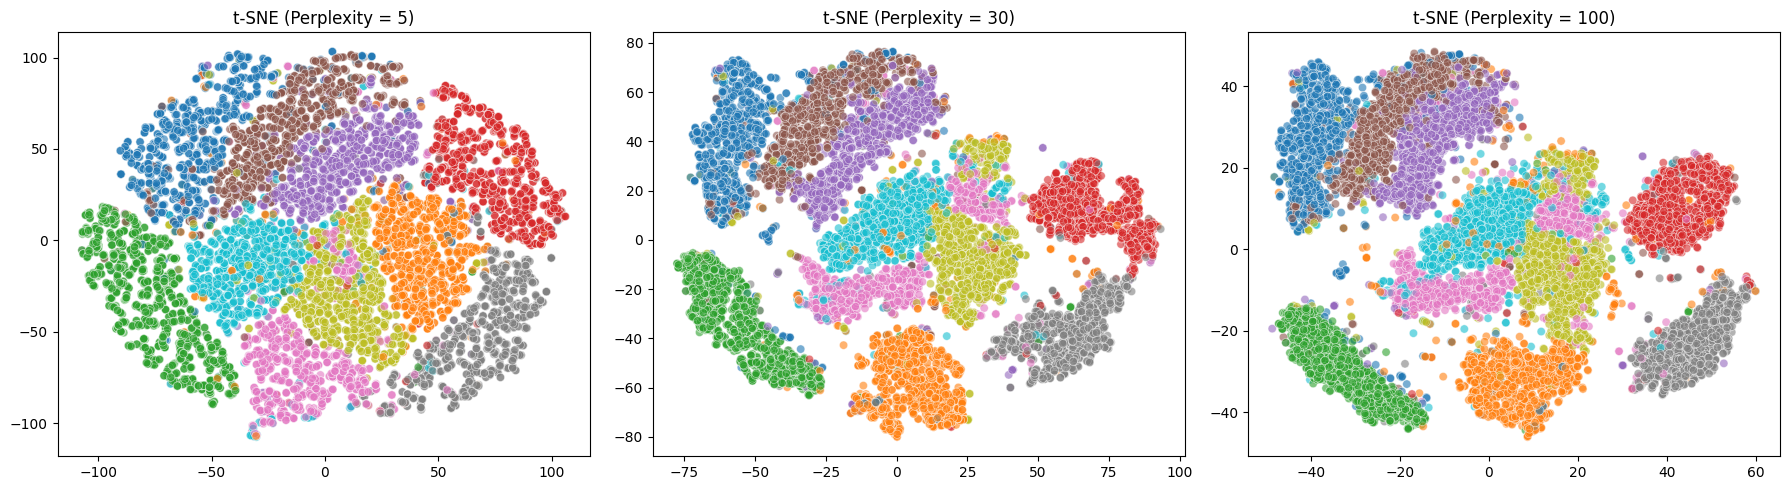

In [9]:
# --- EXPERIMENT: TUNING t-SNE PERPLEXITY ---
perplexities = [5, 30, 100]
plt.figure(figsize=(18, 5))

for i, p in enumerate(perplexities):
    # Run t-SNE with the current perplexity
    tsne_exp = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne_exp = tsne_exp.fit_transform(X_pca) # We still use our 50 PCA components!
    
    # Create a subplot for each
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(
        x=X_tsne_exp[:, 0], y=X_tsne_exp[:, 1],
        hue=y.astype(str), palette='tab10', legend=False, alpha=0.6
    )
    plt.title(f't-SNE (Perplexity = {p})')

plt.tight_layout()
plt.show()

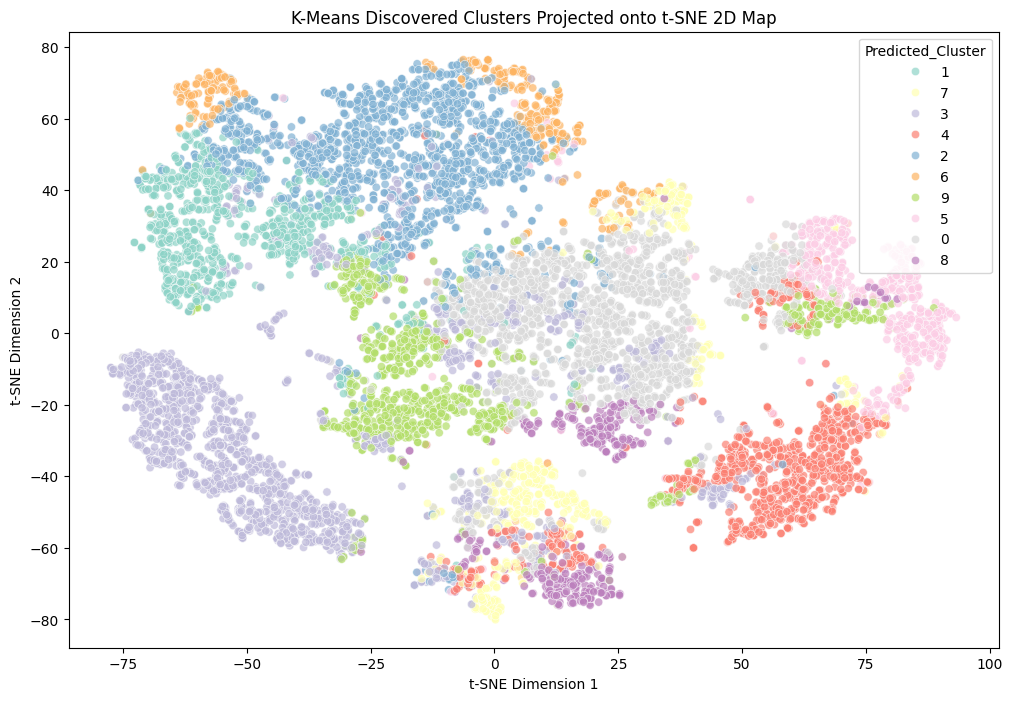

In [10]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. First, let's make sure our plotting dataframe exists 
# (This grabs the X_tsne coordinates you generated earlier)
tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim_1', 'Dim_2'])

# 2. Ask K-Means to find 10 clusters in our 50-dimensional PCA data
# (It does this without looking at the true labels!)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

# 3. Add these predictions to our plotting dataframe
tsne_df['Predicted_Cluster'] = predicted_clusters.astype(str)

# 4. Plot the K-Means clusters on the t-SNE map

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Dim_1', 
    y='Dim_2',
    hue='Predicted_Cluster', 
    palette='Set3', # Using a different pastel color palette so it stands out
    data=tsne_df, 
    legend="full", 
    alpha=0.7
)

plt.title('K-Means Discovered Clusters Projected onto t-SNE 2D Map')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [11]:
import plotly.express as px

# Reduce to 3 dimensions instead of 2
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_pca)

# Create an interactive 3D plot
fig = px.scatter_3d(
    x=X_tsne_3d[:, 0], y=X_tsne_3d[:, 1], z=X_tsne_3d[:, 2],
    color=y.astype(str), opacity=0.7,
    title="Interactive 3D t-SNE Visualization of MNIST",
    color_discrete_sequence=px.colors.qualitative.Plotly
)

# This will open an interactive graph in your browser or notebook!
fig.show()